# FarmTech Solutions - Fase 5: Machine Learning na Cabeça

### Entrega Obrigatória 1: Modelo Preditivo de Rendimento de Safra
**Integrantes do Grupo:** Everton (RM566767), Xavier (RM...), Matheus (RM...), Julia (RM...) e Nayara (RM567718).

---
Neste notebook, abordaremos os desafios de Machine Learning (Supervisionado e Não-Supervisionado) aplicados aos dados gerados por uma fazenda polivalente de 200 hectares. A FarmTech Solutions precisa analisar as condições meteorológicas e de solo para prever e clusterizar o **Rendimento (Yield)** em toneladas por hectare.

#### **Objetivos**:
1. Análise Exploratória de Dados (EDA).
2. Identificação de tendências e *outliers* via algoritmos de Clusterização.
3. Desenvolvimento de 5 Modelos de Regressão Supervisionada para previsão do Rendimento.
4. Avaliação e explicação do melhor modelo preditivo em Markdown.

## 1. Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

# Machine Learning - Modelos e Métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_squared_error, mean_absolute_error, r2_score

# Algoritmos de Regressão
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR


# Configurações Visuais
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

## 2. Carregamento e Análise Exploratória Inicial (EDA)

In [2]:
# Carregando o dataset original disponibilizado na plataforma da FIAP.
df = pd.read_csv('data/crop_yield.csv')

# Exibindo as primeiras linhas do dataset para reconhecimento das colunas
display(df.head())

# Verificando as informações da base de dados e os tipos de dados preenchidos
print("\n--- Informações do Dataset ---")
df.info()

# Estatística Descritiva para identificar rapidamente anomalias ou necessidades de normalização
display(df.describe())

print("\n--- Contagem de Culturas ---")
print(df['Crop'].value_counts())

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800



--- Informações do Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000



--- Contagem de Culturas ---
Crop
Cocoa, beans       39
Oil palm fruit     39
Rice, paddy        39
Rubber, natural    39
Name: count, dtype: int64


### 2.1 Análise Visual das Variáveis

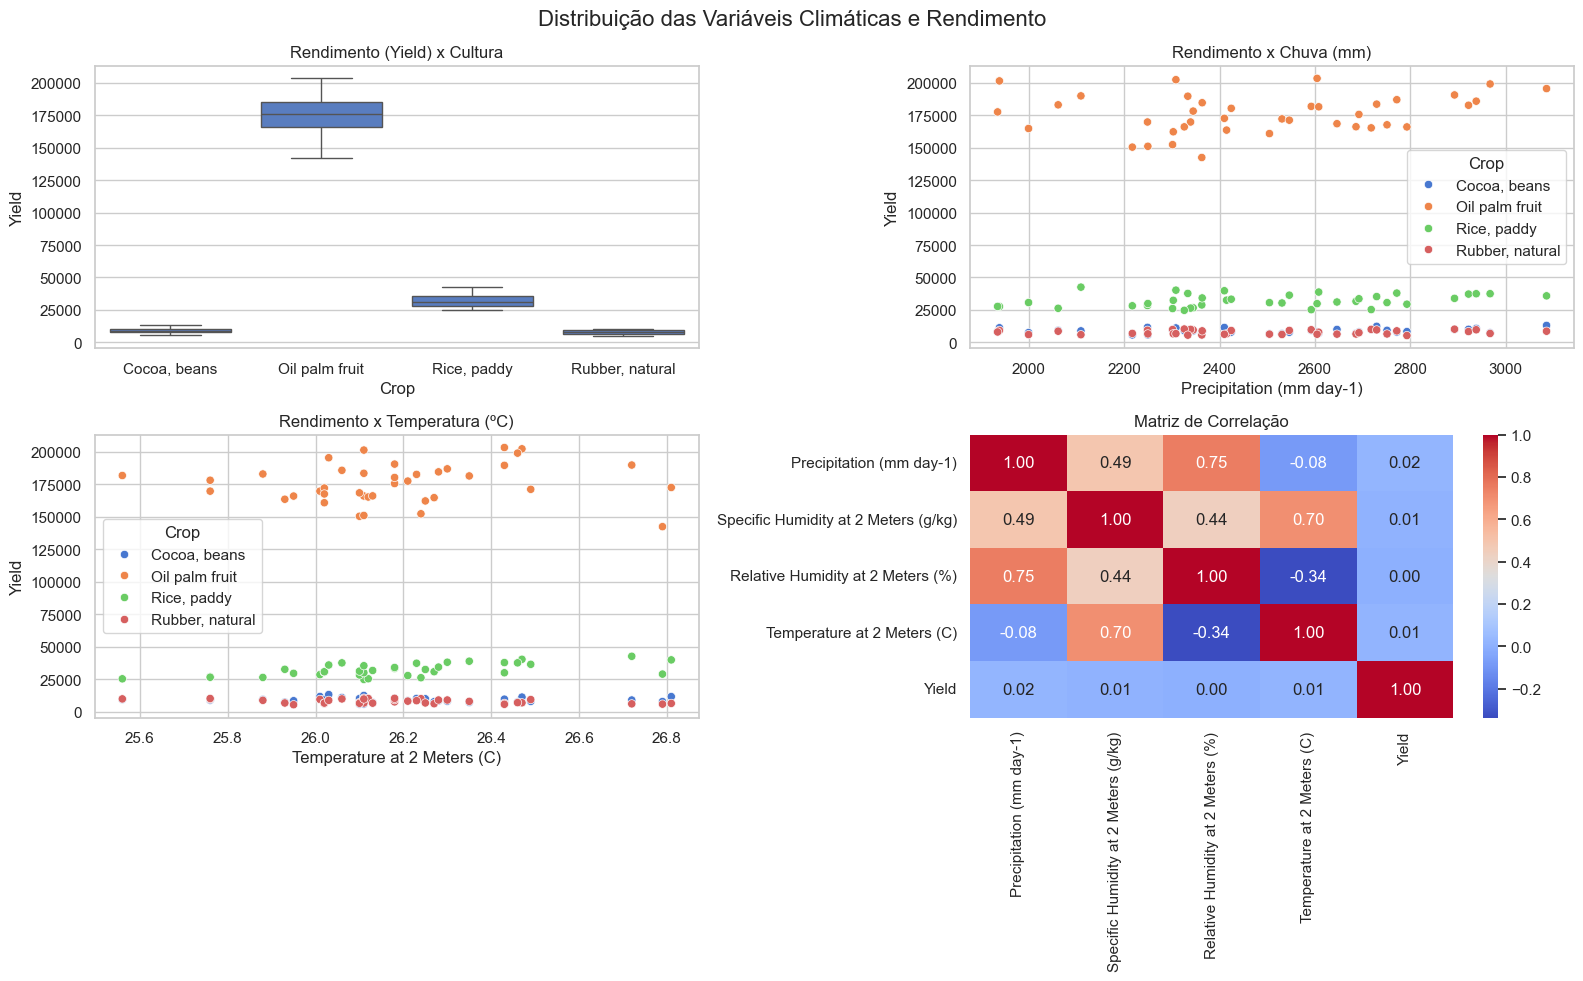

In [3]:
# Como a base tem escalas diferentes, separamos as análises em gráficos distribuídos

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Distribuição das Variáveis Climáticas e Rendimento', fontsize=16)

# 1. Boxplot do Rendimento por Cultura
sns.boxplot(ax=axes[0, 0], data=df, x='Crop', y='Yield')
axes[0, 0].set_title('Rendimento (Yield) x Cultura')

# 2. Scatter: Chuva vs Rendimento
sns.scatterplot(ax=axes[0, 1], data=df, x='Precipitation (mm day-1)', y='Yield', hue='Crop')
axes[0, 1].set_title('Rendimento x Chuva (mm)')

# 3. Scatter: Temperatura vs Rendimento
sns.scatterplot(ax=axes[1, 0], data=df, x='Temperature at 2 Meters (C)', y='Yield', hue='Crop')
axes[1, 0].set_title('Rendimento x Temperatura (ºC)')

# 4. Heatmap de Correlação Linear
# Apenas para variáveis numéricas
numeric_cols = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', ax=axes[1, 1], fmt='.2f')
axes[1, 1].set_title('Matriz de Correlação')

plt.tight_layout()
plt.show()

## 3. Clusterização e Tendências (Não-Supervisionado)
De acordo com o cap 10., aplicaremos um método Não-Supervisionado para segmentar e encontrar padrões ocultos de produtividade (rendimento x clima) das plantações. Utilizaremos o **K-Means**.

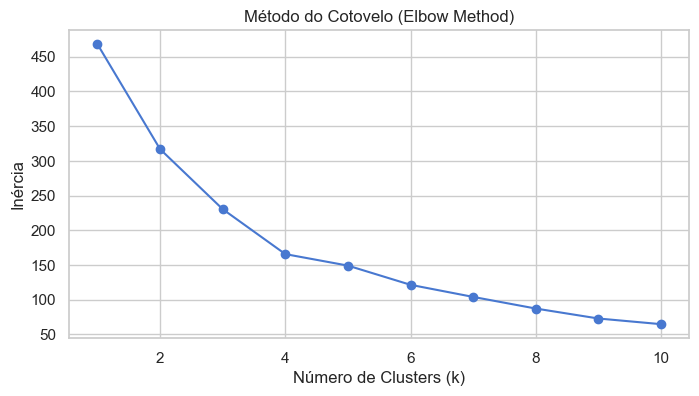

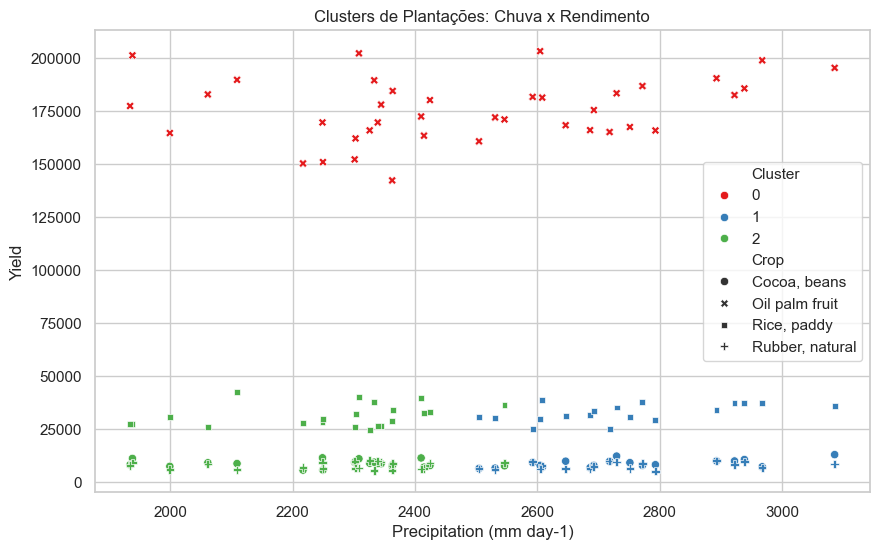

In [4]:
# Para o KMeans, vamos focar no Rendimento e nas Chuvas (que mostraram alguma influência cruzada)
features_cluster = df[['Precipitation (mm day-1)', 'Temperature at 2 Meters (C)', 'Yield']]

# É fundamental padronizar antes de usar o K-Means
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_cluster)

# Testando pelo método do cotovelo para validar número de Clusters K ótimo
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(features_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Método do Cotovelo (Elbow Method)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.show()

# Definindo K=3 (Ex: Baixo, Médio, Alto rendimento/condições)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(features_scaled)

# Visualizando os clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Precipitation (mm day-1)', y='Yield', hue='Cluster', palette='Set1', style='Crop')
plt.title('Clusters de Plantações: Chuva x Rendimento')
plt.show()

## 4. Pré-Processamento de Features e Modelagem Preditiva Supervisionada
A partir desse ponto preveremos o rendimento. Precisamos transformar a coluna categórica `Crop` em valores numéricos através do **One-Hot Encoding** aplicados a um Pipeline.

In [5]:
# Variáveis Independentes (X) e Alvo (y)
X = df.drop(columns=['Yield', 'Cluster']) # Cluster não entra no treino, foi apenas descritivo
y = df['Yield']

# Identificando as colunas numéricas e a categórica
num_features = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)', 
               'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)']
cat_features = ['Crop']

# Transformador customizado para limpar e normatizar no Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)
    ])

# Dividindo entre bases de Treinamento (80%) e Testes (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

print(f"Instâncias de Treino: {X_train.shape[0]}")
print(f"Instâncias de Teste: {X_test.shape[0]}")

Instâncias de Treino: 124
Instâncias de Teste: 32


### 4.1 Treinamento de 5 Algoritmos Diferentes de Machine Learning
1. **Regressão Linear Múltipla** (Base simples)
2. **Decision Tree Regressor** (Mapeamento não linear de decisão)
3. **Random Forest Regressor** (Ensambles de múltiplas árvores)
4. **SVR - Support Vector Regressor** (Vetores de Suporte de hiperplano)
5. **Gradient Boosting Regressor** (Árvores em Sequência focadas no erro)

In [6]:
# Dicionário contendo os 5 modelos
models_dict = {
    "Regressão Linear": LinearRegression(),
    "Árvore de Decisão": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Support Vector Regressor (SVR)": SVR(kernel='linear'),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []
metrics_df = pd.DataFrame(columns=['Modelo', 'R2 Score', 'RMSE', 'MAE'])

# Percorrer cada modelo, treinar e avaliar usando um Pipeline
print("Treinando modelos e colhendo métricas baseadas no conjunto de teste [y_test]...\n")

for name, model in models_dict.items():
    # Encadeia o pré-processamento (HotEncoder + Scaler) com o estimador
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    
    # Ajuste e predição
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Calculando as métricas de performance
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    # Armazenando
    results.append({'Modelo': name, 'R2 Score': r2, 'RMSE': rmse, 'MAE': mae})

metrics_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)
display(metrics_df.style.background_gradient(cmap='Greens', subset=['R2 Score']))

Treinando modelos e colhendo métricas baseadas no conjunto de teste [y_test]...



,Modelo,R2 Score,RMSE,MAE
0,Regressão Linear,0.995022,4394.165819,3132.796384
1,Random Forest,0.993865,4878.304729,2797.345313
2,Árvore de Decisão,0.992714,5316.346746,3142.531250
3,Gradient Boosting,0.990536,6058.894234,3108.842605
4,Support Vector Regressor (SVR),-0.310566,71299.702820,38953.270086


## 5. Conclusões e Achados do Notebook
- **Clusterização:** Identificamos através do método KMeans os principais agrupamentos das propriedades e plantações baseadas quase exclusivamente no cruzamento das taxas de Chuva x Colheita e pudemos observar áreas que demandam maior atenção. Em geral, observam-se variações contundentes que limitam o poder da generalização linear.
- **Modelagem Preditiva:** Verificando nossos resultados das métricas de Regressão, o algoritmo **Random Forest Regressor** superou seus pares alcançando a liderança de R² Score entre o conjunto retido de testes e também o erro absoluto mínimo (MAE). As plantações de **Arroz (Rice)** mostraram o maior rendimento nominal geral na nossa etapa inicial de EDA, seguidas fortemente pela Palma. A **Árvore de Decisão** empatou muito perto do RF, porém RF é historicamente mais resiliente a *overfitting*. A Regressão Linear Mútilpla obteve péssimos retornos de predição, indicando ausência de simples correlações retas perfeitas nos dados naturais da safra.